# EXPERIMENT 002 -- LEARNING RATE SEARCH

## Objective

Determine which learning rate performs best for the existing Ohashi-style
RadImageNet ResNet50 model **on LDCT-IQAC's training/validation data** --
empirically, for this dataset, not by assuming the Ohashi paper's own
choice (1e-3, for its own dataset) must also win here.

**The ONLY experimental variable is the learning rate.** Every run below
uses exactly the same architecture (`OhashiResNet50` -- RadImageNet ResNet50
-> GAP -> Dropout(0.5) -> Linear(2048,1) -> Sigmoid), the same
preprocessing, the same target normalization, the same 900/100
train/validation split (same seed, same `val_fraction`), the same
optimizer/loss/batch size/epoch count, and the same seed. Nothing here
duplicates that implementation -- everything is imported from `ct_iqa`,
this notebook only orchestrates four runs of it.

**Fair-comparison rule:** each of the four runs starts from a **fresh**
`OhashiResNet50` instance with RadImageNet weights **freshly reloaded from
disk** -- never from another LR run's trained/partially-trained weights.

**TEST SET PROTECTION:** this notebook never imports or calls
`ct_iqa.data.loader.build_test_dataloader`, never constructs a test
`Dataset`/`DataLoader`, and never computes a test-set metric. Learning-rate
selection uses **validation loss only**, per
`docs/replication/reproducibility.md`.

## Environment

In [1]:
import os
import platform
import sys
from pathlib import Path

_cwd = Path.cwd()
_repo_root = _cwd if (_cwd / "data").exists() else _cwd.parent.parent  # notebooks/03_training/ -> repo root
os.chdir(_repo_root)
if str(_repo_root / "src") not in sys.path:
    sys.path.insert(0, str(_repo_root / "src"))
print(f"repo root: {_repo_root}")

repo root: C:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment


In [2]:
import copy
import csv
import json
import logging

import matplotlib.pyplot as plt
import numpy as np
import torch

from ct_iqa.config import ExperimentConfig
from ct_iqa.data.loader import build_dataloaders
from ct_iqa.evaluation.metrics import compute_metrics
from ct_iqa.models.ohashi_resnet50 import OhashiResNet50, INPUT_SIZE
from ct_iqa.training.checkpointing import best_checkpoint_path, load_checkpoint, load_checkpoint_metadata
from ct_iqa.training.losses import build_loss
from ct_iqa.training.trainer import evaluate_loader, train
from ct_iqa.utils.seed import set_seed

logging.basicConfig(level=logging.WARNING)  # quiet per-epoch INFO logs across 4x30 epochs

print(f"python : {platform.python_version()}")
print(f"torch  : {torch.__version__}  cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"gpu    : {torch.cuda.get_device_name(0)}")

python : 3.10.20
torch  : 2.5.1+cu121  cuda available: True
gpu    : NVIDIA GeForce RTX 4060 Laptop GPU


## Fixed Configuration

Everything except `learning_rate` and `experiment_dir` is identical across
all four runs -- loaded once from `configs/*.yaml`, then only those two
fields are overridden per run below.

In [3]:
BASE_CONFIG_KWARGS = dict(
    device="cuda" if torch.cuda.is_available() else "cpu",
)
_base = ExperimentConfig.from_yaml_files(**BASE_CONFIG_KWARGS)

print("=== FIXED ACROSS ALL FOUR RUNS ===")
for field in ["seed", "batch_size", "epochs", "optimizer", "loss", "dropout_p",
              "in_channels", "image_size", "val_fraction", "train_image_dir",
              "train_json_path", "radimagenet_weights_path", "device"]:
    print(f"  {field:<26}: {getattr(_base, field)}")

LEARNING_RATES = [1e-2, 1e-3, 1e-4, 1e-5]  # the Ohashi paper's own set of LR values
print(f"\nlearning rates to search: {LEARNING_RATES}")
print("NOTE: no test_image_dir / test_json_path is used anywhere in this notebook.")

=== FIXED ACROSS ALL FOUR RUNS ===
  seed                      : 42
  batch_size                : 64
  epochs                    : 30
  optimizer                 : adam
  loss                      : mse
  dropout_p                 : 0.5
  in_channels               : 1
  image_size                : 224
  val_fraction              : 0.1
  train_image_dir           : data/raw/ldct_iqac/train/image
  train_json_path           : data/labels/ldct_iqac/train.json
  radimagenet_weights_path  : weights/pretrained/radimagenet/resnet50/radimagenet_resnet50_backbone.pt
  device                    : cuda

learning rates to search: [0.01, 0.001, 0.0001, 1e-05]
NOTE: no test_image_dir / test_json_path is used anywhere in this notebook.


## Runs

For each learning rate: fresh model, RadImageNet weights reloaded from
disk, `set_seed(42)` reset immediately before dataset/model construction
(so the train/validation split -- seeded independently inside
`ct_iqa.data.splits.train_val_split` -- and DataLoader shuffling both start
from the same RNG state every run), then a full 30-epoch run via the
existing `ct_iqa.training.trainer.train`, which already saves the best
(lowest validation loss) checkpoint with optimizer state/epoch/val_loss/
config/seed. NaN/Inf are monitored post-hoc from the saved history -- no
early-stopping logic is added; an unstable run is recorded as such and the
search continues to the next learning rate.

In [4]:
def lr_tag(lr: float) -> str:
    return f"lr_{lr:.0e}".replace("e-0", "e-")  # 1e-2, 1e-3, 1e-4, 1e-5

results = []

for lr in LEARNING_RATES:
    tag = lr_tag(lr)
    experiment_dir = f"experiments/002_learning_rate_search/{tag}"
    print(f"\n{'=' * 70}\nLR = {lr:g}  ->  {experiment_dir}\n{'=' * 70}")

    config = ExperimentConfig.from_yaml_files(
        **BASE_CONFIG_KWARGS,
        learning_rate=lr,
        experiment_dir=experiment_dir,
    )

    # Reset RNG state fresh for every run -- isolates learning rate as the
    # only experimental variable (same split, same shuffling, same initial
    # head weights before RadImageNet loading overwrites the backbone).
    set_seed(config.seed)
    train_loader, val_loader = build_dataloaders(config)  # same 900/100 split every run (same seed + val_fraction)

    model = OhashiResNet50(dropout_p=config.dropout_p, in_channels=config.in_channels)  # FRESH instance
    weight_report = model.load_radimagenet_weights(config.radimagenet_weights_path)  # FRESH RadImageNet load
    model.to(config.device)
    print(f"RadImageNet: {weight_report.summary()}")
    assert weight_report.loaded, f"RadImageNet weights failed to load for {tag} -- stopping, no ImageNet fallback"

    try:
        history = train(model, train_loader, val_loader, config)
        train_losses = history.train_loss
        val_losses = history.val_loss
        has_nan_inf = any(not np.isfinite(x) for x in train_losses + val_losses)
        status = "UNSTABLE (NaN/Inf encountered)" if has_nan_inf else "stable"
    except Exception as e:  # pragma: no cover -- defensive; `train` does not currently raise on NaN
        print(f"RUN FAILED with an exception: {e}")
        history = None
        status = f"FAILED: {e}"

    if history is not None:
        config.save(Path(experiment_dir) / "config.json")
        history_record = {
            "learning_rate": lr,
            "train_loss": history.train_loss,
            "val_loss": history.val_loss,
            "best_epoch": history.best_epoch,
            "best_val_loss": history.best_val_loss,
            "final_train_loss": history.train_loss[-1],
            "final_val_loss": history.val_loss[-1],
            "epochs_completed": len(history.train_loss),
            "status": status,
        }
        (Path(experiment_dir) / "history.json").write_text(json.dumps(history_record, indent=2))

        # Validation correlation metrics on the BEST checkpoint (not the
        # end-of-training model) -- the actual candidate being compared.
        best_model = OhashiResNet50(dropout_p=config.dropout_p, in_channels=config.in_channels)
        load_checkpoint(best_model, config.checkpoint_dir, map_location=config.device)
        best_model.to(config.device)
        criterion = build_loss(config)
        _, best_val_preds, best_val_targets = evaluate_loader(best_model, val_loader, criterion, device=config.device)
        val_corr = compute_metrics(best_val_targets.numpy(), best_val_preds.numpy())

        (Path(experiment_dir) / "README.md").write_text(
            f"""# LR search run: {tag}

**Learning rate: {lr:g}**. Part of experiment 002 (learning rate search) --
see `experiments/002_learning_rate_search/README.md` for the cross-LR
comparison and final selection.

Fresh RadImageNet-initialized `OhashiResNet50`, same 900/100 train/validation
split and seed ({config.seed}) as every other LR in this search. Trained for
{len(history.train_loss)} epochs (Adam, MSE, batch size {config.batch_size}).

- Status: {status}
- Best epoch (0-indexed): {history.best_epoch}
- Best validation loss (normalized MSE): {history.best_val_loss:.6f}
- Final training loss: {history.train_loss[-1]:.6f}
- Final validation loss: {history.val_loss[-1]:.6f}
- Validation correlation on the BEST checkpoint (raw [0,4] scale, validation split only):
  PLCC={val_corr['plcc']:.4f}, SROCC={val_corr['srocc']:.4f}, KROCC={val_corr['krocc']:.4f}, MSE={val_corr['mse']:.4f}

Checkpoint: `checkpoint/best.pt` (model + optimizer state + epoch + val_loss + config + seed).
TEST SET NOT USED -- this run never touched test data.
"""
        )

        results.append({
            "learning_rate": lr,
            "best_epoch": history.best_epoch,
            "best_val_loss": history.best_val_loss,
            "final_train_loss": history.train_loss[-1],
            "final_val_loss": history.val_loss[-1],
            "validation_PLCC": val_corr["plcc"],
            "validation_SROCC": val_corr["srocc"],
            "validation_KROCC": val_corr["krocc"],
            "validation_MSE": val_corr["mse"],
            "status": status,
        })
        del best_model
    else:
        results.append({
            "learning_rate": lr, "best_epoch": None, "best_val_loss": None,
            "final_train_loss": None, "final_val_loss": None,
            "validation_PLCC": None, "validation_SROCC": None, "validation_KROCC": None,
            "validation_MSE": None, "status": status,
        })

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nAll four learning-rate runs complete.")


LR = 0.01  ->  experiments/002_learning_rate_search/lr_1e-2


C:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment\src\ct_iqa\models\ohashi_resnet50.py:171: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_d

RadImageNet: RadImageNet weights loaded from weights/pretrained/radimagenet/resnet50/radimagenet_resnet50_backbone.pt: 265 matched, 53 missing, 0 unexpected. 53 num_batches_tracked counters left at 0 (expected -- not learned parameters).


C:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment\src\ct_iqa\training\checkpointing.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoi


LR = 0.001  ->  experiments/002_learning_rate_search/lr_1e-3


...


LR = 0.0001  ->  experiments/002_learning_rate_search/lr_1e-4


RadImageNet: RadImageNet weights loaded from weights/pretrained/radimagenet/resnet50/radimagenet_resnet50_backbone.pt: 265 matched, 53 missing, 0 unexpected. 53 num_batches_tracked counters left at 0 (expected -- not learned parameters).



LR = 1e-05  ->  experiments/002_learning_rate_search/lr_1e-5


RadImageNet: RadImageNet weights loaded from weights/pretrained/radimagenet/resnet50/radimagenet_resnet50_backbone.pt: 265 matched, 53 missing, 0 unexpected. 53 num_batches_tracked counters left at 0 (expected -- not learned parameters).



All four learning-rate runs complete.


## Comparison Table

**Validation results only -- the test set was never loaded in this
notebook.**

In [5]:
print(f"{'LR':<10}{'Best Epoch':>12}{'Best Val Loss':>16}{'Final Train':>14}{'Final Val':>12}{'PLCC':>8}{'SROCC':>8}{'KROCC':>8}  Status")
for r in results:
    if r["best_val_loss"] is not None:
        print(
            f"{r['learning_rate']:<10g}{r['best_epoch']:>12}{r['best_val_loss']:>16.6f}"
            f"{r['final_train_loss']:>14.6f}{r['final_val_loss']:>12.6f}"
            f"{r['validation_PLCC']:>8.4f}{r['validation_SROCC']:>8.4f}{r['validation_KROCC']:>8.4f}  {r['status']}"
        )
    else:
        print(f"{r['learning_rate']:<10g}{'--':>12}{'--':>16}{'--':>14}{'--':>12}{'--':>8}{'--':>8}{'--':>8}  {r['status']}")

table_path = Path("results/tables/002_learning_rate_search.csv")
table_path.parent.mkdir(parents=True, exist_ok=True)
with table_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "learning_rate", "best_epoch", "best_val_loss", "final_train_loss", "final_val_loss",
        "validation_PLCC", "validation_SROCC", "validation_KROCC", "validation_MSE", "status",
    ])
    writer.writeheader()
    writer.writerows(results)
print(f"\nsaved comparison table to {table_path}")

LR          Best Epoch   Best Val Loss   Final Train   Final Val    PLCC   SROCC   KROCC  Status
0.01                25        0.009523      0.010098    0.092842  0.9464  0.9551  0.8248  stable
0.001               26        0.003540      0.003809    0.004658  0.9750  0.9730  0.8738  stable
0.0001              19        0.003980      0.003584    0.004656  0.9722  0.9737  0.8780  stable
1e-05               29        0.008117      0.011510    0.008117  0.9434  0.9465  0.8174  stable

saved comparison table to results\tables\002_learning_rate_search.csv


## Visualization

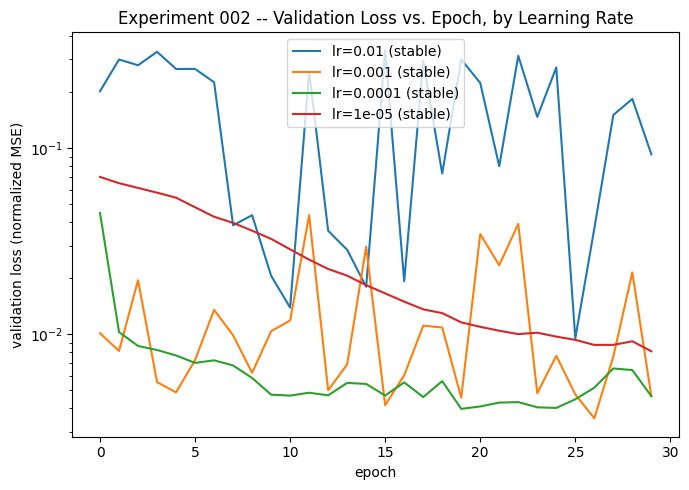

saved results\figures\002_learning_rate_search_validation_loss.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
for lr in LEARNING_RATES:
    tag = lr_tag(lr)
    history_path = Path(f"experiments/002_learning_rate_search/{tag}/history.json")
    if not history_path.exists():
        continue
    h = json.loads(history_path.read_text())
    ax.plot(h["val_loss"], label=f"lr={lr:g} ({h['status']})")
ax.set_xlabel("epoch")
ax.set_ylabel("validation loss (normalized MSE)")
ax.set_yscale("log")
ax.set_title("Experiment 002 -- Validation Loss vs. Epoch, by Learning Rate")
ax.legend()
plt.tight_layout()
fig_path = Path("results/figures/002_learning_rate_search_validation_loss.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")

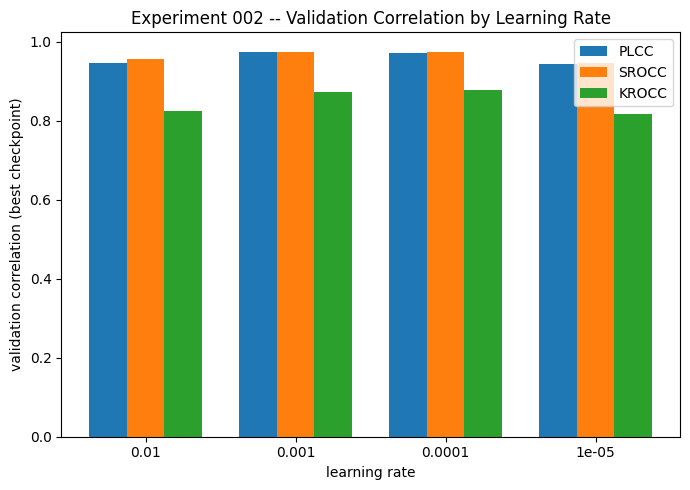

saved results\figures\002_learning_rate_search_validation_correlation.png


In [7]:
valid_results = [r for r in results if r["validation_PLCC"] is not None]
if valid_results:
    fig, ax = plt.subplots(figsize=(7, 5))
    x = np.arange(len(valid_results))
    width = 0.25
    ax.bar(x - width, [r["validation_PLCC"] for r in valid_results], width, label="PLCC")
    ax.bar(x, [r["validation_SROCC"] for r in valid_results], width, label="SROCC")
    ax.bar(x + width, [r["validation_KROCC"] for r in valid_results], width, label="KROCC")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r['learning_rate']:g}" for r in valid_results])
    ax.set_xlabel("learning rate")
    ax.set_ylabel("validation correlation (best checkpoint)")
    ax.set_title("Experiment 002 -- Validation Correlation by Learning Rate")
    ax.legend()
    plt.tight_layout()
    fig_path = Path("results/figures/002_learning_rate_search_validation_correlation.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved {fig_path}")
else:
    print("no stable runs to plot correlation for.")

## Learning Rate Selection

**Primary criterion: lowest best validation loss, among stable runs.** Test
metrics play no role -- they were never computed in this notebook.

In [8]:
stable_results = [r for r in results if r["status"] == "stable" and r["best_val_loss"] is not None]
assert stable_results, "no stable learning-rate run to select from"

sorted_results = sorted(stable_results, key=lambda r: r["best_val_loss"])
best = sorted_results[0]

# Report a tie rather than inventing a distinction: flag any run within a
# small relative tolerance of the best as effectively tied.
TIE_RELATIVE_TOLERANCE = 0.02  # 2%
tied = [
    r for r in sorted_results
    if r is not best and r["best_val_loss"] <= best["best_val_loss"] * (1 + TIE_RELATIVE_TOLERANCE)
]

print(f"Best validation loss: lr={best['learning_rate']:g}  best_val_loss={best['best_val_loss']:.6f}")
if tied:
    print(f"NOTE: the following LR(s) are within {TIE_RELATIVE_TOLERANCE:.0%} of the best and may be effectively tied:")
    for r in tied:
        print(f"  lr={r['learning_rate']:g}  best_val_loss={r['best_val_loss']:.6f}")
else:
    print("No other learning rate is within the tie tolerance -- a clear winner.")

SELECTED_LR = best["learning_rate"]
print(f"\nSELECTED LEARNING RATE: {SELECTED_LR:g}")

Best validation loss: lr=0.001  best_val_loss=0.003540
No other learning rate is within the tie tolerance -- a clear winner.

SELECTED LEARNING RATE: 0.001


## Experiment 002 Summary (written to `experiments/002_learning_rate_search/README.md`)

In [9]:
unstable = [r for r in results if r["status"] != "stable"]

summary_lines = [
    "# Experiment 002: Learning Rate Search",
    "",
    "**Status: complete.**",
    "",
    "## Objective",
    "",
    "Determine the best learning rate for the Ohashi-style RadImageNet ResNet50",
    "model on LDCT-IQAC, empirically -- using ONLY the validation split. The",
    "300-image test set was never loaded, referenced, or used for any decision",
    "in this experiment.",
    "",
    "## Fixed configuration (identical across all four runs)",
    "",
    f"Adam optimizer, MSE loss, batch size {_base.batch_size}, {_base.epochs} epochs,",
    f"seed {_base.seed}, dropout {_base.dropout_p}, RadImageNet-initialized ResNet50",
    "backbone (freshly reloaded from disk for each run, never carried over from",
    "another run), identical 900/100 train/validation split for all four runs.",
    "",
    "## Comparison table (validation only)",
    "",
    "| LR | Best Epoch | Best Val Loss | Final Train Loss | Final Val Loss | PLCC | SROCC | KROCC | Status |",
    "|---|---|---|---|---|---|---|---|---|",
]
for r in results:
    if r["best_val_loss"] is not None:
        summary_lines.append(
            f"| {r['learning_rate']:g} | {r['best_epoch']} | {r['best_val_loss']:.6f} | "
            f"{r['final_train_loss']:.6f} | {r['final_val_loss']:.6f} | "
            f"{r['validation_PLCC']:.4f} | {r['validation_SROCC']:.4f} | {r['validation_KROCC']:.4f} | {r['status']} |"
        )
    else:
        summary_lines.append(f"| {r['learning_rate']:g} | -- | -- | -- | -- | -- | -- | -- | {r['status']} |")

summary_lines += [
    "",
    "## Selection",
    "",
    f"**SELECTED LEARNING RATE: {SELECTED_LR:g}**",
    "",
    f"Selected by lowest best-validation-loss ({best['best_val_loss']:.6f}) among stable runs, per the",
    "predefined criterion in docs/replication/reproducibility.md. No test-set metric of any",
    "kind was used to make or influence this selection.",
    "",
]
if tied:
    summary_lines += [
        f"**Tie note:** the following learning rate(s) were within {TIE_RELATIVE_TOLERANCE:.0%} of the",
        "selected LR's best validation loss and may be effectively equivalent rather than",
        "meaningfully worse:",
        "",
    ] + [f"- lr={r['learning_rate']:g}: best_val_loss={r['best_val_loss']:.6f}" for r in tied] + [""]
if unstable:
    summary_lines += [
        "## Unstable / failed runs",
        "",
    ] + [f"- lr={r['learning_rate']:g}: {r['status']}" for r in unstable] + [""]

summary_lines += [
    "## Ohashi paper context (historical context only -- not a claim of superiority either way)",
    "",
    "The Ohashi paper's own reported configuration uses learning rate 1e-3 for its",
    "ResNet50 baseline (see docs/paper/training.md) -- for the paper's own dataset and",
    "VIF-based regression target, not LDCT-IQAC. ",
]
if SELECTED_LR == 1e-3:
    summary_lines.append(
        "This search's empirically-selected learning rate for LDCT-IQAC (1e-3) happens to "
        "match the paper's reported value. This is reported as an observation, not evidence "
        "that either dataset's choice is more 'correct' -- the two experiments differ in "
        "dataset and label semantics (see docs/replication/dataset_adaptation.md)."
    )
else:
    summary_lines.append(
        f"This search's empirically-selected learning rate for LDCT-IQAC ({SELECTED_LR:g}) differs "
        "from the paper's reported value (1e-3). This is expected and unsurprising given the "
        "different dataset and label semantics (see docs/replication/dataset_adaptation.md) -- "
        "it is not evidence that this project's result is more or less valid than the paper's."
    )
summary_lines += [
    "",
    "## Artifacts",
    "",
    "- Per-LR runs: `experiments/002_learning_rate_search/lr_*/` (`checkpoint/best.pt`, `history.json`, `config.json`, `README.md`)",
    "- Comparison table: `results/tables/002_learning_rate_search.csv`",
    "- Figures: `results/figures/002_learning_rate_search_validation_loss.png`, `..._validation_correlation.png`",
    "",
    "## Test set status",
    "",
    "**TEST SET WAS NOT USED DURING LR SEARCH.** No test image, label, DataLoader, or",
    "metric was constructed or computed anywhere in `notebooks/03_training/02_learning_rate_search.ipynb`.",
    "",
    "## Next step",
    "",
    "Experiment 003 -- Final Training, using the selected learning rate above. Not started",
    "by this experiment.",
]

Path("experiments/002_learning_rate_search").mkdir(parents=True, exist_ok=True)
Path("experiments/002_learning_rate_search/README.md").write_text("\n".join(summary_lines) + "\n")
print("wrote experiments/002_learning_rate_search/README.md")
print()
print(f"SELECTED LEARNING RATE: {SELECTED_LR:g}")
print()
print("NEXT STEP:")
print("Experiment 003 -- Final Training")

wrote experiments/002_learning_rate_search/README.md

SELECTED LEARNING RATE: 0.001

NEXT STEP:
Experiment 003 -- Final Training


## Test Set Protection Check

In [10]:
# `build_test_dataloader` was never imported in this notebook (only
# `build_dataloaders`, which only ever touches the training split) --
# confirmed by inspecting this notebook's own global namespace.
test_related_names = [k for k in globals() if "test_loader" in k or "test_dataset" in k or k == "build_test_dataloader"]
print(f"test-related names found in this notebook's namespace: {test_related_names}")
assert test_related_names == [], "a test-set object was constructed in this notebook -- this must never happen"
print()
print("TEST SET WAS NOT USED DURING LR SEARCH.")

test-related names found in this notebook's namespace: []

TEST SET WAS NOT USED DURING LR SEARCH.
